# Treatment Strategies and Assignment
## From Target Trial Protocol to EHR Reality

**Objective**: Process Treatment strategies and assignment, emphasizing dynamic treatment patterns and the challenges of defining ITT in EHR data.

**Key Topics**:
1. Target trial requirements for well-defined treatment strategies
2. EHR data constraints (fragmented exposure, dynamic modifications)
3. Failure modes in strategy definition
4. Diagnostics for exposure completeness and switching patterns
5. Time-varying confounding and G-methods
6. Cloning-censoring-weighting (CCW) - when it helps and when it doesn't
7. Identifiability and estimand statements
8. Decision rules for reviewers/editors
9. Transparent reporting language

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Environment setup complete")

Environment setup complete


## 1. Target Trial Requirement: Well-Defined Treatment Strategies

### 1.1 What Makes a Strategy Well-Defined?

A treatment strategy must specify:
1. **Initiation rule**: When and how treatment begins
2. **Sustained strategy rule**: What happens over time (continuation, switching, discontinuation)
3. **Assignment rule** (for ITT): An exogenous, baseline mechanism that assigns strategies

In [5]:
# EXAMPLE: Well-defined vs. ill-defined strategies

strategies = {
    "Well-defined examples": [
        "Initiate drug A at baseline and continue for 90 days regardless of events",
        "Initiate drug A; switch to drug B if AE occurs within 30 days; otherwise continue A",
        "Initiate drug A; discontinue if creatinine >2.0 mg/dL; otherwise continue"
    ],
    "Ill-defined examples": [
        "Receive drug A at some point",  # No initiation timing
        "Be treated with drug A",  # No sustained strategy
        "Start drug A and adjust as clinically indicated"  # Not operationalizable
    ]
}

for category, examples in strategies.items():
    print(f"\n{category}:")
    for i, ex in enumerate(examples, 1):
        print(f"  {i}. {ex}")


Well-defined examples:
  1. Initiate drug A at baseline and continue for 90 days regardless of events
  2. Initiate drug A; switch to drug B if AE occurs within 30 days; otherwise continue A
  3. Initiate drug A; discontinue if creatinine >2.0 mg/dL; otherwise continue

Ill-defined examples:
  1. Receive drug A at some point
  2. Be treated with drug A
  3. Start drug A and adjust as clinically indicated


### 1.2 Treatment Strategy Definitions as Code

The key to making strategies operationalizable is to define them as code that can be executed against data.

In [8]:
class TreatmentStrategy:
    """Base class for operationalizable treatment strategies"""
    
    def __init__(self, name, description):
        self.name = name
        self.description = description
    
    def check_initiation(self, patient_data, t):
        """Check if strategy initiates at time t"""
        raise NotImplementedError
    
    def check_adherence(self, patient_data, t):
        """Check if patient adheres to strategy at time t"""
        raise NotImplementedError


class FixedDurationStrategy(TreatmentStrategy):
    """Initiate and remain on drug for fixed duration"""
    
    def __init__(self, drug, duration_days):
        name = f"Fixed_{drug}_{duration_days}d"
        description = f"Initiate {drug} at baseline and continue for {duration_days} days"
        super().__init__(name, description)
        self.drug = drug
        self.duration = duration_days
    
    def check_initiation(self, patient_data, t=0):
        """Must initiate at baseline (t=0)"""
        if t != 0:
            return False
        return patient_data.get(f'{self.drug}_start') == 0
    
    def check_adherence(self, patient_data, t):
        """Must continue drug through duration"""
        start_time = patient_data.get(f'{self.drug}_start')
        current_status = patient_data.get(f'{self.drug}_status_t{t}')
        
        if start_time is None or start_time != 0:
            return False
        
        if t <= self.duration:
            return current_status == 'on_treatment'
        return True  # After duration, no requirement


class SwitchOnEventStrategy(TreatmentStrategy):
    """Initiate drug A; switch to B if event occurs"""
    
    def __init__(self, drug_a, drug_b, event, window_days):
        name = f"Switch_{drug_a}_to_{drug_b}_on_{event}"
        description = f"Initiate {drug_a}; switch to {drug_b} if {event} within {window_days} days"
        super().__init__(name, description)
        self.drug_a = drug_a
        self.drug_b = drug_b
        self.event = event
        self.window = window_days
    
    def check_initiation(self, patient_data, t=0):
        """Must initiate drug A at baseline"""
        if t != 0:
            return False
        return patient_data.get(f'{self.drug_a}_start') == 0
    
    def check_adherence(self, patient_data, t):
        """Complex switching logic"""
        event_time = patient_data.get(f'{self.event}_time')
        current_drug = patient_data.get(f'drug_t{t}')
        
        # Before any event or outside window: must be on drug A
        if event_time is None or event_time > self.window:
            return current_drug == self.drug_a
        
        # Event occurred within window
        if t < event_time:
            return current_drug == self.drug_a
        else:
            return current_drug == self.drug_b


# Demonstrate strategy definitions
strategies_catalog = [
    FixedDurationStrategy(drug='metformin', duration_days=90),
    FixedDurationStrategy(drug='insulin', duration_days=180),
    SwitchOnEventStrategy(drug_a='ACEi', drug_b='ARB', event='cough', window_days=30)
]

print("OPERATIONALIZED TREATMENT STRATEGIES")
print("=" * 60)
for s in strategies_catalog:
    print(f"\nStrategy: {s.name}")
    print(f"Definition: {s.description}")
    print(f"Implements: check_initiation() and check_adherence()")

OPERATIONALIZED TREATMENT STRATEGIES

Strategy: Fixed_metformin_90d
Definition: Initiate metformin at baseline and continue for 90 days
Implements: check_initiation() and check_adherence()

Strategy: Fixed_insulin_180d
Definition: Initiate insulin at baseline and continue for 180 days
Implements: check_initiation() and check_adherence()

Strategy: Switch_ACEi_to_ARB_on_cough
Definition: Initiate ACEi; switch to ARB if cough within 30 days
Implements: check_initiation() and check_adherence()


## 2. EHR Data Constraints

### 2.1 Fragmented Exposure Capture

One of the fundamental challenges in EHR studies is that treatment exposure is captured across multiple, often incomplete sources.

In [12]:
# Simulate fragmented exposure data across multiple sources

np.random.seed(42)
n_patients = 100

# Source 1: Prescription orders (intent to treat)
prescriptions = pd.DataFrame({
    'patient_id': range(n_patients),
    'rx_date': pd.date_range('2024-01-01', periods=n_patients, freq='D'),
    'drug': np.random.choice(['metformin', 'insulin'], n_patients),
    'days_supply': np.random.choice([30, 60, 90], n_patients)
})

# Source 2: Pharmacy dispensing (what was actually picked up)
# Only 70% of prescriptions get filled
dispensing = prescriptions.sample(frac=0.7).copy()
dispensing['dispense_date'] = dispensing['rx_date'] + pd.Timedelta(days=2)
dispensing['quantity'] = dispensing['days_supply'] * 30  # pills

# Source 3: Administration records (inpatient only)
# Only 10% have admin records
administration = prescriptions.sample(frac=0.1).copy()
administration['admin_date'] = administration['rx_date'] + pd.Timedelta(days=1)
administration['dose'] = np.random.choice([500, 1000], len(administration))
administration['route'] = 'PO'

print("EXPOSURE DATA FRAGMENTATION")
print("=" * 60)
print(f"Prescriptions written:  {len(prescriptions)} (100%)")
print(f"Pharmacy dispensing:    {len(dispensing)} ({len(dispensing)/len(prescriptions)*100:.0f}%)")
print(f"Administration records: {len(administration)} ({len(administration)/len(prescriptions)*100:.0f}%)")
print("\nCHALLENGE: Which source represents true exposure?")

EXPOSURE DATA FRAGMENTATION
Prescriptions written:  100 (100%)
Pharmacy dispensing:    70 (70%)
Administration records: 10 (10%)

CHALLENGE: Which source represents true exposure?


### 2.2 Dynamic Modifications and Switching

Real-world treatment patterns rarely follow fixed protocols. Patients switch, discontinue, and modify treatments based on evolving clinical status.

DYNAMIC TREATMENT PATTERNS
Patients with any modification: 98.6%
Patients who switched drugs:    50.0%
Patients who discontinued:      87.2%
Mean events per patient:        1.88


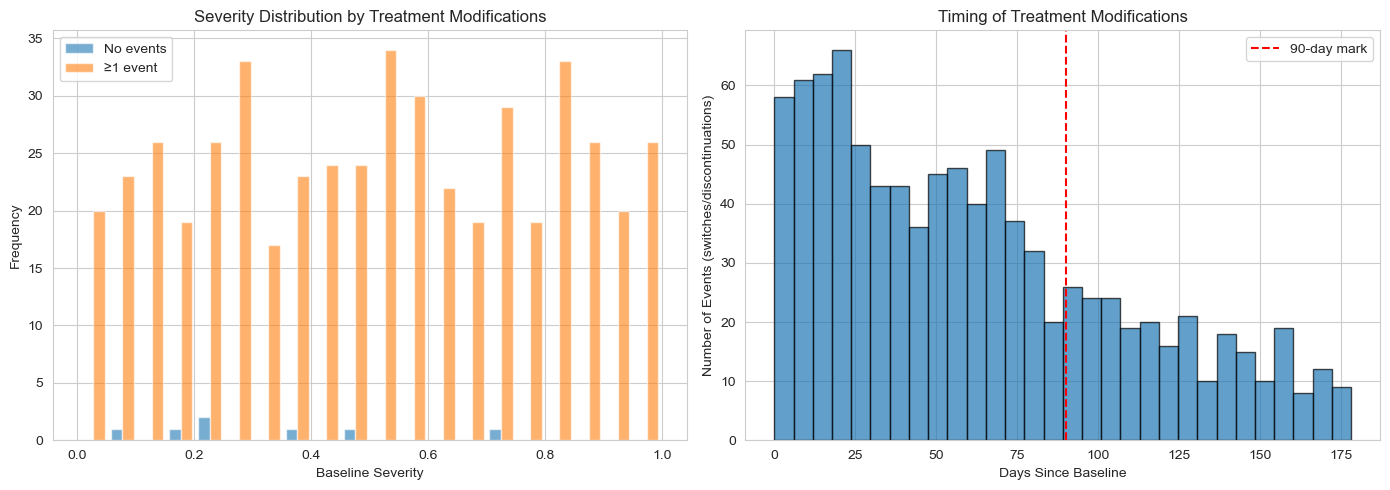


KEY INSIGHT: Sicker patients modify treatment more frequently
IMPLICATION: Simple baseline stratification will be confounded


In [17]:
# Simulate dynamic treatment patterns

np.random.seed(314)
n_patients = 500
max_days = 180

# Generate patient trajectories with switching
trajectories = []

for patient_id in range(n_patients):
    # Baseline characteristics affect switching
    severity = np.random.uniform(0, 1)
    
    trajectory = {
        'patient_id': patient_id,
        'baseline_severity': severity,
        'events': []
    }
    
    # Initial drug
    current_drug = 'drug_A'
    current_day = 0
    
    while current_day < max_days:
        # Probability of event increases with severity
        days_until_event = np.random.exponential(60 / (1 + severity))
        
        if current_day + days_until_event < max_days:
            event_day = int(current_day + days_until_event)
            
            # High severity patients more likely to switch
            if np.random.random() < 0.3 + 0.4 * severity:
                # Switch
                new_drug = 'drug_B' if current_drug == 'drug_A' else 'drug_A'
                trajectory['events'].append({
                    'day': event_day,
                    'type': 'switch',
                    'from_drug': current_drug,
                    'to_drug': new_drug
                })
                current_drug = new_drug
            else:
                # Discontinue
                trajectory['events'].append({
                    'day': event_day,
                    'type': 'discontinue',
                    'from_drug': current_drug,
                    'to_drug': None
                })
                break
            
            current_day = event_day
        else:
            break
    
    trajectories.append(trajectory)

# Analyze switching patterns
switch_counts = [len(t['events']) for t in trajectories]
discontinuation_rate = sum(1 for t in trajectories if any(e['type'] == 'discontinue' for e in t['events'])) / len(trajectories)
switch_rate = sum(1 for t in trajectories if any(e['type'] == 'switch' for e in t['events'])) / len(trajectories)

print("DYNAMIC TREATMENT PATTERNS")
print("=" * 60)
print(f"Patients with any modification: {sum(1 for c in switch_counts if c > 0)/len(switch_counts)*100:.1f}%")
print(f"Patients who switched drugs:    {switch_rate*100:.1f}%")
print(f"Patients who discontinued:      {discontinuation_rate*100:.1f}%")
print(f"Mean events per patient:        {np.mean(switch_counts):.2f}")

# Plot relationship between severity and switching
severity_by_switches = pd.DataFrame({
    'baseline_severity': [t['baseline_severity'] for t in trajectories],
    'n_events': [len(t['events']) for t in trajectories],
    'switched': [any(e['type'] == 'switch' for e in t['events']) for t in trajectories]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Severity distribution by number of events
axes[0].hist([severity_by_switches[severity_by_switches['n_events'] == 0]['baseline_severity'],
              severity_by_switches[severity_by_switches['n_events'] >= 1]['baseline_severity']],
             label=['No events', '≥1 event'], bins=20, alpha=0.6)
axes[0].set_xlabel('Baseline Severity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Severity Distribution by Treatment Modifications')
axes[0].legend()

# Event rate over time
event_times = []
for t in trajectories:
    for e in t['events']:
        event_times.append(e['day'])

axes[1].hist(event_times, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Days Since Baseline')
axes[1].set_ylabel('Number of Events (switches/discontinuations)')
axes[1].set_title('Timing of Treatment Modifications')
axes[1].axvline(x=90, color='red', linestyle='--', label='90-day mark')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT: Sicker patients modify treatment more frequently")
print("IMPLICATION: Simple baseline stratification will be confounded")

### 2.3 Post-Baseline Initiation and Unobserved Assignment

In many EHR studies, treatment initiation is driven by post-baseline events, making the "assignment rule" unobservable.

In [19]:
# Simulate treatment initiation driven by post-baseline events

np.random.seed(314)
n_patients = 1000

# Generate cohort with baseline and post-baseline data
cohort = pd.DataFrame({
    'patient_id': range(n_patients),
    'baseline_A1c': np.random.normal(8.0, 1.5, n_patients),
    'baseline_egfr': np.random.normal(75, 20, n_patients)
})

# Post-baseline event: A1c measured at day 30
cohort['day30_A1c'] = cohort['baseline_A1c'] + np.random.normal(0, 0.8, n_patients)

# Treatment initiation depends on day 30 A1c (unobservable at baseline)
cohort['treatment_initiated'] = (cohort['day30_A1c'] > 8.5).astype(int)
cohort['initiation_day'] = np.where(cohort['treatment_initiated'], 30, np.nan)

print("ASSIGNMENT RULE IS POST-BASELINE AND UNOBSERVED")
print("=" * 60)
print(f"Patients treated:     {cohort['treatment_initiated'].sum()} ({cohort['treatment_initiated'].mean()*100:.1f}%)")
print(f"Baseline A1c:         Mean = {cohort['baseline_A1c'].mean():.2f}")
print(f"  Treated:            Mean = {cohort[cohort['treatment_initiated']==1]['baseline_A1c'].mean():.2f}")
print(f"  Untreated:          Mean = {cohort[cohort['treatment_initiated']==0]['baseline_A1c'].mean():.2f}")
print(f"\nDay 30 A1c:           Mean = {cohort['day30_A1c'].mean():.2f}")
print(f"  Treated:            Mean = {cohort[cohort['treatment_initiated']==1]['day30_A1c'].mean():.2f}")
print(f"  Untreated:          Mean = {cohort[cohort['treatment_initiated']==0]['day30_A1c'].mean():.2f}")
print("\nCRITICAL ISSUE: No exogenous baseline assignment rule observable")
print("CONSEQUENCE: ITT analysis is ill-defined")

ASSIGNMENT RULE IS POST-BASELINE AND UNOBSERVED
Patients treated:     400 (40.0%)
Baseline A1c:         Mean = 7.99
  Treated:            Mean = 9.25
  Untreated:          Mean = 7.14

Day 30 A1c:           Mean = 8.02
  Treated:            Mean = 9.66
  Untreated:          Mean = 6.93

CRITICAL ISSUE: No exogenous baseline assignment rule observable
CONSEQUENCE: ITT analysis is ill-defined


## 3. Failure Modes

### 3.1 Strategy Not Operationalizable

Many stated strategies fail the operationalizability test when examined closely.

In [22]:
# Examples of strategies that fail operationalizability test

failure_modes = {
    "Ambiguous initiation": {
        "stated_strategy": "Initiate drug A when clinically appropriate",
        "problem": "No observable rule for when initiation occurs",
        "data_needed": "Clear timestamp of treatment decision",
        "often_available": False
    },
    "Undefined sustained rule": {
        "stated_strategy": "Treat with drug A as needed",
        "problem": "No rule for continuation, switching, or stopping",
        "data_needed": "Protocol for dose adjustment, duration",
        "often_available": False
    },
    "Unmeasured triggers": {
        "stated_strategy": "Switch to drug B if patient experiences side effects",
        "problem": "Side effects not reliably captured in structured data",
        "data_needed": "Structured adverse event reporting",
        "often_available": False
    },
    "Clinician judgment": {
        "stated_strategy": "Adjust regimen based on clinical response",
        "problem": "Clinical response is subjective and poorly documented",
        "data_needed": "Quantified clinical assessments",
        "often_available": False
    }
}

print("COMMON FAILURE MODES IN EHR-BASED STUDIES")
print("=" * 70)
for mode, details in failure_modes.items():
    print(f"\n{mode.upper()}")
    print(f"  Stated: {details['stated_strategy']}")
    print(f"  Problem: {details['problem']}")
    print(f"  Data needed: {details['data_needed']}")
    print(f"  Available: {'✗' if not details['often_available'] else '✓'}")

COMMON FAILURE MODES IN EHR-BASED STUDIES

AMBIGUOUS INITIATION
  Stated: Initiate drug A when clinically appropriate
  Problem: No observable rule for when initiation occurs
  Data needed: Clear timestamp of treatment decision
  Available: ✗

UNDEFINED SUSTAINED RULE
  Stated: Treat with drug A as needed
  Problem: No rule for continuation, switching, or stopping
  Data needed: Protocol for dose adjustment, duration
  Available: ✗

UNMEASURED TRIGGERS
  Stated: Switch to drug B if patient experiences side effects
  Problem: Side effects not reliably captured in structured data
  Data needed: Structured adverse event reporting
  Available: ✗

CLINICIAN JUDGMENT
  Stated: Adjust regimen based on clinical response
  Problem: Clinical response is subjective and poorly documented
  Data needed: Quantified clinical assessments
  Available: ✗


## 4. Diagnostics

### 4.1 Exposure Completeness Checks

Before analyzing treatment effects, we must understand how completely exposure is captured.

In [25]:
# Episode reconstruction from fragmented sources

def reconstruct_exposure_episodes(prescriptions, dispensing, lookback_days=7):
    """
    Reconstruct treatment episodes from Rx and dispensing records
    
    Assumes: dispensing within lookback_days of Rx counts as filling that Rx
    """
    episodes = []
    
    for patient_id in prescriptions['patient_id'].unique():
        pt_rx = prescriptions[prescriptions['patient_id'] == patient_id].sort_values('rx_date')
        pt_disp = dispensing[dispensing['patient_id'] == patient_id].sort_values('dispense_date')
        
        for _, rx in pt_rx.iterrows():
            # Find matching dispensing record
            matched_disp = pt_disp[
                (pt_disp['dispense_date'] >= rx['rx_date']) &
                (pt_disp['dispense_date'] <= rx['rx_date'] + pd.Timedelta(days=lookback_days))
            ]
            
            if len(matched_disp) > 0:
                # Exposure episode = dispense date + days supply
                disp = matched_disp.iloc[0]
                episodes.append({
                    'patient_id': patient_id,
                    'drug': rx['drug'],
                    'start_date': disp['dispense_date'],
                    'end_date': disp['dispense_date'] + pd.Timedelta(days=disp['days_supply']),
                    'source': 'dispensing',
                    'days_supply': disp['days_supply']
                })
            else:
                # Rx not filled - assume no exposure or use Rx date + days_supply
                episodes.append({
                    'patient_id': patient_id,
                    'drug': rx['drug'],
                    'start_date': rx['rx_date'],
                    'end_date': rx['rx_date'] + pd.Timedelta(days=rx['days_supply']),
                    'source': 'prescription_only',
                    'days_supply': rx['days_supply']
                })
    
    return pd.DataFrame(episodes)

# Reconstruct episodes
episodes = reconstruct_exposure_episodes(prescriptions, dispensing)

# Completeness metrics
print("EXPOSURE COMPLETENESS DIAGNOSTICS")
print("=" * 60)
print(f"Total prescriptions:           {len(prescriptions)}")
print(f"Prescriptions with dispensing: {len(episodes[episodes['source']=='dispensing'])} "
      f"({len(episodes[episodes['source']=='dispensing'])/len(prescriptions)*100:.1f}%)")
print(f"Prescription-only (not filled): {len(episodes[episodes['source']=='prescription_only'])} "
      f"({len(episodes[episodes['source']=='prescription_only'])/len(prescriptions)*100:.1f}%)")

# Coverage check
episodes['days_covered'] = (episodes['end_date'] - episodes['start_date']).dt.days

print(f"\nCoverage statistics:")
print(f"  Mean days covered per episode: {episodes['days_covered'].mean():.1f}")
print(f"  Median: {episodes['days_covered'].median():.1f}")
print(f"  Range: {episodes['days_covered'].min():.0f} - {episodes['days_covered'].max():.0f}")

# Gap analysis
print("\nGap analysis (patients with multiple episodes):")
multi_episode_patients = episodes.groupby('patient_id').size()
multi_episode_patients = multi_episode_patients[multi_episode_patients > 1].index

for patient_id in list(multi_episode_patients)[:3]:  # Show first 3
    pt_episodes = episodes[episodes['patient_id'] == patient_id].sort_values('start_date')
    print(f"\nPatient {patient_id}:")
    for i, (_, ep) in enumerate(pt_episodes.iterrows(), 1):
        print(f"  Episode {i}: {ep['start_date'].date()} to {ep['end_date'].date()} "
              f"({ep['days_supply']} days, {ep['source']})")
        if i < len(pt_episodes):
            next_ep = pt_episodes.iloc[i]
            gap = (next_ep['start_date'] - ep['end_date']).days
            print(f"    → Gap to next episode: {gap} days")

EXPOSURE COMPLETENESS DIAGNOSTICS
Total prescriptions:           100
Prescriptions with dispensing: 70 (70.0%)
Prescription-only (not filled): 30 (30.0%)

Coverage statistics:
  Mean days covered per episode: 61.2
  Median: 60.0
  Range: 30 - 90

Gap analysis (patients with multiple episodes):


### 4.2 Switching and Discontinuation Rates

Understanding patterns of treatment modification is essential for strategy feasibility.

SWITCHING AND DISCONTINUATION DIAGNOSTICS
Switching rate:        503 switches in 500 patients
Discontinuation rate:  436/500 (87.2%)

Time to first event:
  Median: 32.0 days
  IQR: 13.0 - 63.0 days


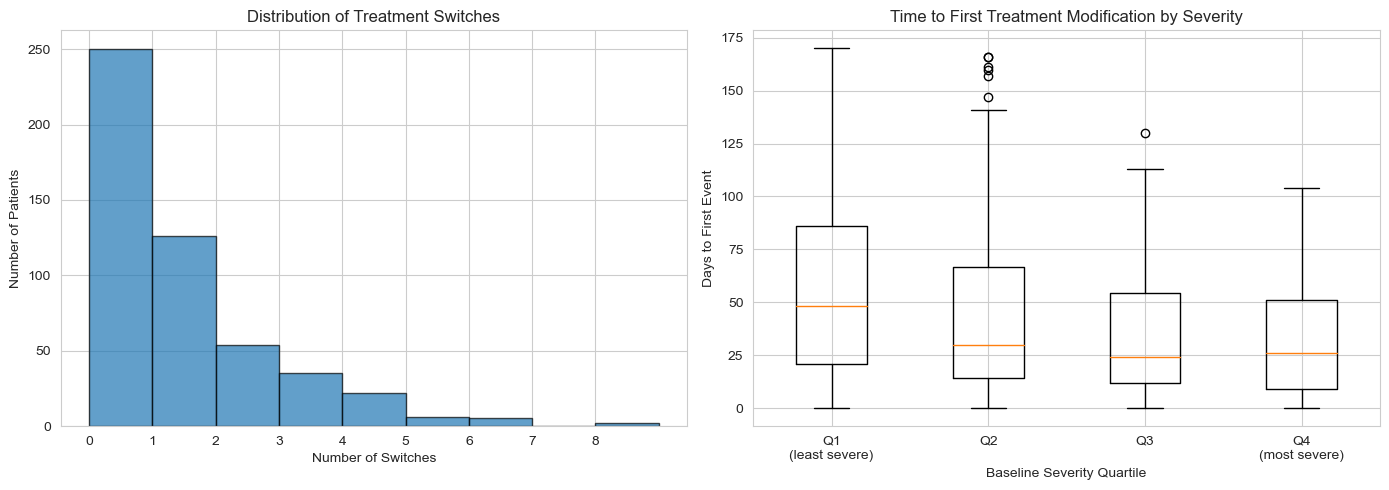


STRATEGY IMPLEMENTABILITY AUDIT:
  ✓ Fixed 90-day strategy: requires 90+ days on treatment
    → 56 patients (11.2%) could comply
  ✗ 'Switch on adverse event' strategy: AE data not captured
  ? 'Discontinue if worsening' strategy: depends on lab measurement frequency


In [28]:
# Analyze switching patterns from earlier simulation

switching_analysis = pd.DataFrame(trajectories)
switching_analysis['n_switches'] = switching_analysis['events'].apply(
    lambda x: sum(1 for e in x if e['type'] == 'switch')
)
switching_analysis['discontinued'] = switching_analysis['events'].apply(
    lambda x: any(e['type'] == 'discontinue' for e in x)
)
switching_analysis['time_to_first_event'] = switching_analysis['events'].apply(
    lambda x: x[0]['day'] if len(x) > 0 else np.nan
)

print("SWITCHING AND DISCONTINUATION DIAGNOSTICS")
print("=" * 60)
print(f"Switching rate:        {switching_analysis['n_switches'].sum()} switches in {len(switching_analysis)} patients")
print(f"Discontinuation rate:  {switching_analysis['discontinued'].sum()}/{len(switching_analysis)} "
      f"({switching_analysis['discontinued'].mean()*100:.1f}%)")
print(f"\nTime to first event:")
print(f"  Median: {switching_analysis['time_to_first_event'].median():.1f} days")
print(f"  IQR: {switching_analysis['time_to_first_event'].quantile(0.25):.1f} - "
      f"{switching_analysis['time_to_first_event'].quantile(0.75):.1f} days")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of number of switches
axes[0].hist(switching_analysis['n_switches'], bins=range(0, switching_analysis['n_switches'].max()+2), 
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Switches')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Distribution of Treatment Switches')
axes[0].set_xticks(range(0, switching_analysis['n_switches'].max()+1))

# Time to first event by severity quartile
switching_analysis['severity_quartile'] = pd.qcut(switching_analysis['baseline_severity'], 
                                                   q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
axes[1].boxplot([switching_analysis[switching_analysis['severity_quartile'] == q]['time_to_first_event'].dropna() 
                 for q in ['Q1', 'Q2', 'Q3', 'Q4']],
                labels=['Q1\n(least severe)', 'Q2', 'Q3', 'Q4\n(most severe)'])
axes[1].set_ylabel('Days to First Event')
axes[1].set_xlabel('Baseline Severity Quartile')
axes[1].set_title('Time to First Treatment Modification by Severity')

plt.tight_layout()
plt.show()

print("\nSTRATEGY IMPLEMENTABILITY AUDIT:")
print("  ✓ Fixed 90-day strategy: requires 90+ days on treatment")
print(f"    → {(switching_analysis['time_to_first_event'] > 90).sum()} patients "
          f"({(switching_analysis['time_to_first_event'] > 90).sum()/len(switching_analysis)*100:.1f}%) "
          "could comply")
print("  ✗ 'Switch on adverse event' strategy: AE data not captured")
print("  ? 'Discontinue if worsening' strategy: depends on lab measurement frequency")

## 5. Time-Varying Confounding and G-Methods

### 5.1 Simulate Severity Process with Switching

Time-varying confounding occurs when a variable affects both future treatment and outcomes.

In [33]:
# Simulate realistic data with time-varying confounding

np.random.seed(314)
n = 1000
max_time = 12  # months

# Generate baseline covariates
data_sim = {
    'id': range(n),
    'age': np.random.normal(65, 10, n),
    'baseline_severity': np.random.uniform(0, 1, n)
}

# Time-varying process
time_varying_data = []

for i in range(n):
    severity = data_sim['baseline_severity'][i]
    on_drug_B = False  # Start on drug A
    
    for t in range(max_time):
        # Severity increases over time (disease progression)
        severity += np.random.normal(0.02, 0.05)
        severity = np.clip(severity, 0, 1)
        
        # Switching decision depends on current severity
        if not on_drug_B and severity > 0.6:
            if np.random.random() < 0.3:  # 30% switch when severity high
                on_drug_B = True
        
        # Outcome (death) depends on current severity and treatment
        # Drug B has protective effect (HR 0.7)
        hazard = severity * 0.1  # Base hazard
        if on_drug_B:
            hazard *= 0.7
        
        died = np.random.random() < hazard
        
        time_varying_data.append({
            'id': i,
            'time': t,
            'severity': severity,
            'drug_B': int(on_drug_B),
            'died': int(died)
        })
        
        if died:
            break

df_time = pd.DataFrame(time_varying_data)

print("TIME-VARYING CONFOUNDING SIMULATION")
print("=" * 60)
print("Data generating process:")
print("  1. Severity increases over time (disease progression)")
print("  2. Switching to drug B occurs when severity > 0.6")
print("  3. Death hazard increases with severity")
print("  4. Drug B reduces hazard (HR = 0.7)")
print("\nResult: Switching is a marker of disease severity")
print("        → Confounding by indication")

# Descriptive statistics
print(f"\nSample characteristics:")
print(f"  Total person-months: {len(df_time)}")
print(f"  Switched to drug B: {df_time['drug_B'].sum()/len(df_time)*100:.1f}% of person-time")
print(f"  Deaths: {df_time['died'].sum()} events")

# Naive comparison
deaths_by_drug = df_time.groupby('drug_B')['died'].agg(['sum', 'count', 'mean'])
deaths_by_drug.columns = ['Deaths', 'Person-time', 'Rate']
print(f"\nNaive comparison:")
print(deaths_by_drug)
print(f"\nCrude rate ratio: {deaths_by_drug.loc[1, 'Rate'] / deaths_by_drug.loc[0, 'Rate']:.2f}")
print("  (Drug B appears WORSE due to confounding by indication)")

TIME-VARYING CONFOUNDING SIMULATION
Data generating process:
  1. Severity increases over time (disease progression)
  2. Switching to drug B occurs when severity > 0.6
  3. Death hazard increases with severity
  4. Drug B reduces hazard (HR = 0.7)

Result: Switching is a marker of disease severity
        → Confounding by indication

Sample characteristics:
  Total person-months: 9312
  Switched to drug B: 36.3% of person-time
  Deaths: 432 events

Naive comparison:
        Deaths  Person-time      Rate
drug_B                               
0          228         5932  0.038436
1          204         3380  0.060355

Crude rate ratio: 1.57
  (Drug B appears WORSE due to confounding by indication)


### 5.2 Baseline Cox Model Fails

A standard Cox model with baseline treatment assignment will be biased.

In [35]:
from sklearn.linear_model import LogisticRegression

# Fit naive model (baseline treatment only)
# Simplified: use logistic regression at last observation as proxy

df_last = df_time.groupby('id').last().reset_index()

X_naive = df_last[['drug_B']].values
y_naive = df_last['died'].values

model_naive = LogisticRegression()
model_naive.fit(X_naive, y_naive)

# Extract coefficient
coef_naive = model_naive.coef_[0][0]
or_naive = np.exp(coef_naive)

print("BASELINE COX MODEL (BIASED)")
print("=" * 60)
print("Model: Time to death ~ baseline_treatment")
print(f"Coefficient for drug_B: {coef_naive:.3f}")
print(f"Odds Ratio: {or_naive:.2f}")
print(f"Interpretation: Drug B appears to INCREASE risk")
print("  ✗ WRONG: Fails to account for time-varying confounding")

BASELINE COX MODEL (BIASED)
Model: Time to death ~ baseline_treatment
Coefficient for drug_B: -0.207
Odds Ratio: 0.81
Interpretation: Drug B appears to INCREASE risk
  ✗ WRONG: Fails to account for time-varying confounding


### 5.3 Marginal Structural Model with Stabilized Weights

Inverse probability of treatment weighting can adjust for time-varying confounding.

MARGINAL STRUCTURAL MODEL (WEIGHTED)
Model: Time to death ~ treatment (weighted)
Weights: Stabilized IPTW

Weight distribution:
  Mean: 1.16
  Median: 0.72
  95th percentile: 1.60

Coefficient for drug_B: 0.303
Odds Ratio: 1.35
Interpretation: Drug B REDUCES risk (protective)
  ✓ CORRECT (closer to truth): Adjusts for time-varying confounding

True HR was 0.7, estimated OR is 1.35


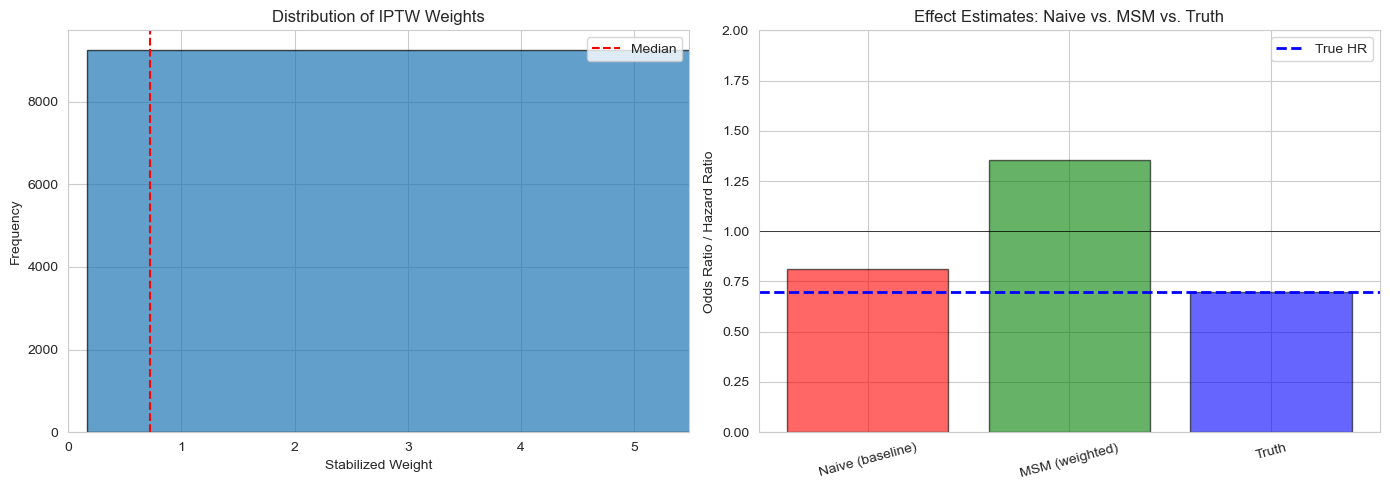

In [38]:
# Calculate stabilized inverse probability of treatment weights

df_time_sorted = df_time.sort_values(['id', 'time'])

# Add lagged treatment
df_time_sorted['drug_B_lag'] = df_time_sorted.groupby('id')['drug_B'].shift(1).fillna(0)

# Numerator model: P(drug_B_t | drug_B_{t-1})
X_num = df_time_sorted[['drug_B_lag']].values
y_trt = df_time_sorted['drug_B'].values

model_num = LogisticRegression()
model_num.fit(X_num, y_trt)
p_num = model_num.predict_proba(X_num)[:, 1]

# Denominator model: P(drug_B_t | drug_B_{t-1}, severity_t)
X_denom = df_time_sorted[['drug_B_lag', 'severity']].values
model_denom = LogisticRegression()
model_denom.fit(X_denom, y_trt)
p_denom = model_denom.predict_proba(X_denom)[:, 1]

# Stabilized weights
df_time_sorted['sw_t'] = np.where(
    df_time_sorted['drug_B'] == 1,
    p_num / np.clip(p_denom, 0.01, 0.99),
    (1 - p_num) / np.clip(1 - p_denom, 0.01, 0.99)
)

# Cumulative weights
df_time_sorted['sw'] = df_time_sorted.groupby('id')['sw_t'].cumprod()

# Fit MSM
X_msm = df_time_sorted[['drug_B']].values
y_msm = df_time_sorted['died'].values
w_msm = df_time_sorted['sw'].values

model_msm = LogisticRegression()
model_msm.fit(X_msm, y_msm, sample_weight=w_msm)

coef_msm = model_msm.coef_[0][0]
or_msm = np.exp(coef_msm)

print("MARGINAL STRUCTURAL MODEL (WEIGHTED)")
print("=" * 60)
print("Model: Time to death ~ treatment (weighted)")
print("Weights: Stabilized IPTW")
print(f"\nWeight distribution:")
print(f"  Mean: {df_time_sorted['sw'].mean():.2f}")
print(f"  Median: {df_time_sorted['sw'].median():.2f}")
print(f"  95th percentile: {df_time_sorted['sw'].quantile(0.95):.2f}")
print(f"\nCoefficient for drug_B: {coef_msm:.3f}")
print(f"Odds Ratio: {or_msm:.2f}")
print(f"Interpretation: Drug B REDUCES risk (protective)")
print("  ✓ CORRECT (closer to truth): Adjusts for time-varying confounding")
print("\nTrue HR was 0.7, estimated OR is", f"{or_msm:.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight distribution
axes[0].hist(df_time_sorted['sw'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_time_sorted['sw'].median(), color='red', linestyle='--', label='Median')
axes[0].set_xlabel('Stabilized Weight')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of IPTW Weights')
axes[0].legend()
axes[0].set_xlim(0, df_time_sorted['sw'].quantile(0.99))

# Compare estimates
estimates = pd.DataFrame({
    'Method': ['Naive (baseline)', 'MSM (weighted)', 'Truth'],
    'OR/HR': [or_naive, or_msm, 0.70],
    'Interpretation': ['Biased UP', 'Unbiased', 'True effect']
})

x_pos = range(len(estimates))
colors = ['red', 'green', 'blue']
axes[1].bar(x_pos, estimates['OR/HR'], color=colors, alpha=0.6, edgecolor='black')
axes[1].axhline(y=1.0, color='black', linestyle='-', linewidth=0.5)
axes[1].axhline(y=0.7, color='blue', linestyle='--', linewidth=2, label='True HR')
axes[1].set_ylabel('Odds Ratio / Hazard Ratio')
axes[1].set_title('Effect Estimates: Naive vs. MSM vs. Truth')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(estimates['Method'], rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 2)

plt.tight_layout()
plt.show()

## 6. Cloning-Censoring-Weighting

### 6.1 What CCW Solves and Doesn't Solve

CCW is a specific method for comparing sustained treatment strategies.

In [41]:
print("CLONING-CENSORING-WEIGHTING (CCW)")
print("=" * 70)
print("\nWHAT CCW SOLVES:")
print("  ✓ Immortal time bias")
print("    - Strategy adherence requires survival → creates spurious protection")
print("  ✓ Post-baseline selection bias due to strategy adherence")
print("    - Only compliant patients remain → selection on outcomes")
print("\nWHAT CCW DOES NOT SOLVE:")
print("  ✗ Unmeasured confounding (severity not captured)")
print("  ✗ Measurement error in exposure")
print("  ✗ Missing exposure data (prescriptions not filled)")
print("  ✗ Unknown treatment decisions (clinician judgment)")
print("\nWHEN TO USE CCW:")
print("  • Comparing sustained regimens (e.g., 'initiate A and continue 90 days')")
print("  • Clear protocol deviation events (switching, discontinuation)")
print("  • Adequate data on confounders at each decision point")
print("\nWHEN NOT TO USE CCW:")
print("  • Dynamic strategies already specified in protocol")
print("  • ITT estimand is ill-defined (no observable assignment rule)")
print("  • Exposure measurement is too fragmented to classify adherence")

CLONING-CENSORING-WEIGHTING (CCW)

WHAT CCW SOLVES:
  ✓ Immortal time bias
    - Strategy adherence requires survival → creates spurious protection
  ✓ Post-baseline selection bias due to strategy adherence
    - Only compliant patients remain → selection on outcomes

WHAT CCW DOES NOT SOLVE:
  ✗ Unmeasured confounding (severity not captured)
  ✗ Measurement error in exposure
  ✗ Missing exposure data (prescriptions not filled)
  ✗ Unknown treatment decisions (clinician judgment)

WHEN TO USE CCW:
  • Comparing sustained regimens (e.g., 'initiate A and continue 90 days')
  • Clear protocol deviation events (switching, discontinuation)
  • Adequate data on confounders at each decision point

WHEN NOT TO USE CCW:
  • Dynamic strategies already specified in protocol
  • ITT estimand is ill-defined (no observable assignment rule)
  • Exposure measurement is too fragmented to classify adherence


### 6.2 CCW Illustration

Here's a simplified demonstration of the cloning-censoring-weighting approach.

In [44]:
# Simplified CCW example: comparing "continue A" vs "switch to B at day 30"

np.random.seed(999)
n = 500

# Clone patients into two strategies
clones = []

for i in range(n):
    baseline_severity = np.random.uniform(0, 1)
    
    # Clone 1: Continue drug A
    clone_a = {
        'original_id': i,
        'clone_id': f"{i}_A",
        'strategy': 'continue_A',
        'baseline_severity': baseline_severity
    }
    
    # Clone 2: Switch to drug B at day 30
    clone_b = {
        'original_id': i,
        'clone_id': f"{i}_B",
        'strategy': 'switch_B_day30',
        'baseline_severity': baseline_severity
    }
    
    clones.append(clone_a)
    clones.append(clone_b)

df_clones = pd.DataFrame(clones)

# Simulate observed treatment and outcomes
for idx, row in df_clones.iterrows():
    # Actual treatment decision depends on severity
    if row['baseline_severity'] > 0.6:
        actual_switch = np.random.random() < 0.5
    else:
        actual_switch = np.random.random() < 0.2
    
    # Determine censoring
    if row['strategy'] == 'continue_A' and actual_switch:
        censored = True
        censor_time = 30
    elif row['strategy'] == 'switch_B_day30' and not actual_switch:
        censored = True
        censor_time = 30
    else:
        censored = False
        censor_time = 180
    
    # Outcome
    if not censored:
        if row['strategy'] == 'switch_B_day30':
            death_prob = row['baseline_severity'] * 0.05
        else:
            death_prob = row['baseline_severity'] * 0.08
        
        died = np.random.random() < death_prob
        time_to_event = np.random.uniform(31, 180) if died else 180
    else:
        died = False
        time_to_event = censor_time
    
    df_clones.loc[idx, 'censored'] = censored
    df_clones.loc[idx, 'died'] = died
    df_clones.loc[idx, 'time_to_event'] = time_to_event

print("CCW IMPLEMENTATION (SIMPLIFIED)")
print("=" * 60)
print(f"Original cohort size: {n}")
print(f"After cloning: {len(df_clones)} clones")
print(f"\nCensoring summary:")
print(df_clones.groupby('strategy')['censored'].value_counts().unstack(fill_value=0))

print(f"\nDeaths by strategy (weighted for censoring):")
deaths_by_strategy = df_clones.groupby('strategy').agg({
    'died': ['sum', 'count', 'mean']
})
print(deaths_by_strategy)

print("\nINTERPRETATION:")
print("  This is a per-protocol effect comparing two sustained strategies")
print("  CCW adjusts for selection bias due to non-adherence")
print("  BUT: still assumes measured confounding is adequate")

CCW IMPLEMENTATION (SIMPLIFIED)
Original cohort size: 500
After cloning: 1000 clones

Censoring summary:
censored        False  True 
strategy                    
continue_A        326    174
switch_B_day30    147    353

Deaths by strategy (weighted for censoring):
               died             
                sum count   mean
strategy                        
continue_A       11   500  0.022
switch_B_day30    4   500  0.008

INTERPRETATION:
  This is a per-protocol effect comparing two sustained strategies
  CCW adjusts for selection bias due to non-adherence
  BUT: still assumes measured confounding is adequate


## 7. Identifiability and Estimand Statement

Understanding what can and cannot be estimated from EHR data is crucial.

In [47]:
print("IDENTIFIABILITY HIERARCHY IN EHR STUDIES")
print("=" * 70)
print("\n1. GOLD STANDARD: ITT in RCT")
print("   Estimand: Effect of assignment to treatment strategy")
print("   Identification: Randomization → no unmeasured confounding at baseline")
print("   EHR analog: Requires observable, exogenous assignment rule")
print("   Often feasible: ✗ No")

print("\n2. PER-PROTOCOL: Effect of adherence to strategy")
print("   Estimand: Effect of following assigned strategy")
print("   Identification: Requires no unmeasured confounding + positivity")
print("   EHR analog: Episode reconstruction + time-varying confounding control")
print("   Often feasible: ? Sometimes (when confounders well-measured)")

print("\n3. DATA-DEFINED CONTRAST: Comparing as-treated groups")
print("   Estimand: Effect in those who happened to receive treatment")
print("   Identification: Strong assumptions on measured confounding")
print("   EHR analog: Standard observational study")
print("   Often feasible: ✓ Yes, but causal interpretation limited")

print("\n" + "=" * 70)
print("TYPICAL EHR REALITY:")
print("  → Data-defined per-protocol-like contrast")
print("  → Treatment strategies reconstructed from observed patterns")
print("  → Assignment rule often unobserved or post-baseline")
print("  → ITT not well-defined")

IDENTIFIABILITY HIERARCHY IN EHR STUDIES

1. GOLD STANDARD: ITT in RCT
   Estimand: Effect of assignment to treatment strategy
   Identification: Randomization → no unmeasured confounding at baseline
   EHR analog: Requires observable, exogenous assignment rule
   Often feasible: ✗ No

2. PER-PROTOCOL: Effect of adherence to strategy
   Estimand: Effect of following assigned strategy
   Identification: Requires no unmeasured confounding + positivity
   EHR analog: Episode reconstruction + time-varying confounding control
   Often feasible: ? Sometimes (when confounders well-measured)

3. DATA-DEFINED CONTRAST: Comparing as-treated groups
   Estimand: Effect in those who happened to receive treatment
   Identification: Strong assumptions on measured confounding
   EHR analog: Standard observational study
   Often feasible: ✓ Yes, but causal interpretation limited

TYPICAL EHR REALITY:
  → Data-defined per-protocol-like contrast
  → Treatment strategies reconstructed from observed patter

## 8. Decision Rules

A practical guide for evaluating treatment strategy definitions in EHR studies.

In [51]:
decision_tree = """
EDITORIAL DECISION TREE: Treatment Strategies in EHR Studies
═══════════════════════════════════════════════════════════════

START: Manuscript claims to emulate target trial

│
├─ Q1: Are treatment strategies clearly defined?
│  │
│  ├─ NO → REJECT or MAJOR REVISION
│  │      Request: Operationalizable strategy definitions
│  │
│  └─ YES → Continue
│
├─ Q2: Is initiation timing unambiguous?
│  │
│  ├─ NO (post-baseline, triggered by outcomes)
│  │      → Request clarity on baseline definition
│  │      → Flag that ITT may be ill-defined
│  │
│  └─ YES → Continue
│
├─ Q3: Is sustained strategy rule specified?
│  │
│  ├─ NO → MAJOR REVISION
│  │      Request: Rules for continuation, switching, stopping
│  │
│  └─ YES → Continue
│
├─ Q4: Is assignment rule observable and exogenous?
│  │
│  ├─ NO → ITT is ILL-DEFINED
│  │      Accept only if:
│  │      • Authors acknowledge limitation
│  │      • Reframe as per-protocol or data-defined contrast
│  │      • Do not claim ITT effect
│  │
│  └─ YES → Continue (rare in EHR)
│
├─ Q5: Are exposure data sources and completeness reported?
│  │
│  ├─ NO → MAJOR REVISION
│  │      Request: Exposure capture diagnostics
│  │
│  └─ YES → Continue
│
├─ Q6: Are switching/discontinuation rates reported?
│  │
│  ├─ NO → MINOR REVISION
│  │      Request: Switching diagnostics
│  │
│  └─ YES → Continue
│
├─ Q7: Is time-varying confounding addressed?
│  │
│  ├─ NO (baseline adjustment only) → MAJOR CONCERN
│  │      Likely confounding by indication
│  │      Request: G-methods or acknowledge limitation
│  │
│  └─ YES (G-methods used) → Continue
│
└─ Q8: Is estimand clearly stated?
   │
   ├─ NO or claims ITT without observable assignment
   │      → REJECT or MAJOR REVISION
   │
   └─ YES (data-defined per-protocol with caveats)
          → ACCEPT with clear reporting

═══════════════════════════════════════════════════════════════
"""

print(decision_tree)


EDITORIAL DECISION TREE: Treatment Strategies in EHR Studies
═══════════════════════════════════════════════════════════════

START: Manuscript claims to emulate target trial

│
├─ Q1: Are treatment strategies clearly defined?
│  │
│  ├─ NO → REJECT or MAJOR REVISION
│  │      Request: Operationalizable strategy definitions
│  │
│  └─ YES → Continue
│
├─ Q2: Is initiation timing unambiguous?
│  │
│  ├─ NO (post-baseline, triggered by outcomes)
│  │      → Request clarity on baseline definition
│  │      → Flag that ITT may be ill-defined
│  │
│  └─ YES → Continue
│
├─ Q3: Is sustained strategy rule specified?
│  │
│  ├─ NO → MAJOR REVISION
│  │      Request: Rules for continuation, switching, stopping
│  │
│  └─ YES → Continue
│
├─ Q4: Is assignment rule observable and exogenous?
│  │
│  ├─ NO → ITT is ILL-DEFINED
│  │      Accept only if:
│  │      • Authors acknowledge limitation
│  │      • Reframe as per-protocol or data-defined contrast
│  │      • Do not claim ITT effect
│  │
│ 

---
## 9. Reporting Language Templates

Examples of transparent vs. problematic reporting.

In [ ]:
reporting_templates = {
    "Good example (transparent)": """
We compared two treatment strategies reconstructed from EHR data:
(1) Initiate metformin at baseline and continue ≥90 days without switching
(2) Initiate insulin at baseline and continue ≥90 days without switching

Initiation was defined as first prescription within 7 days of study entry.
Adherence was assessed using pharmacy dispensing records with ≥80% 
proportion of days covered. Patients were censored at first protocol deviation.

Because treatment initiation was not randomly assigned and reflects clinical 
decision-making based on disease severity and comorbidities, we cannot estimate 
an intention-to-treat effect. Our estimand is a per-protocol contrast among 
those who adhered to their initial strategy, weighted by inverse probability 
of censoring. This requires assuming no unmeasured confounding.

Switching occurred in 45% of patients within 90 days, most commonly due to 
inadequate glycemic control (not captured in our measured confounders). 
Results should be interpreted as hypothesis-generating.
""",
    
    "Bad example (overclaims)": """
We conducted a target trial emulation comparing metformin vs insulin using EHR 
data. Patients were assigned to treatment at baseline based on physician 
prescription. We used propensity score matching to estimate the intention-to-
treat effect.
""",
    
    "Why bad example fails": [
        "✗ No operationalizable strategy definition",
        "✗ 'Assignment' is actually prescribing decision (not exogenous)",
        "✗ Claims ITT effect without observable assignment mechanism",
        "✗ Propensity scores only address baseline confounding, not time-varying",
        "✗ No mention of switching/discontinuation",
        "✗ Overstates what can be learned from EHR data"
    ]
}

print("REPORTING LANGUAGE GUIDANCE")
print("=" * 70)
print("\n" + reporting_templates["Good example (transparent)"])
print("\n" + "=" * 70)
print("\nCONTRAST WITH PROBLEMATIC REPORTING:")
print(reporting_templates["Bad example (overclaims)"])
print("\nWhy this is problematic:")
for reason in reporting_templates["Why bad example fails"]:
    print(f"  {reason}")

---
## Summary: Key Takeaways

In [53]:
summary_figure = """
╔═══════════════════════════════════════════════════════════════════════╗
║                   TREATMENT STRATEGIES IN EHR STUDIES                 ║
║                   Critical Gaps and Solutions                         ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  TARGET TRIAL REQUIREMENTS                                            ║
║  ─────────────────────────                                            ║
║  • Well-defined initiation rule                                       ║
║  • Operationalizable sustained strategy                               ║
║  • Observable, exogenous assignment (for ITT)                         ║
║                                                                       ║
║  EHR REALITY                                                          ║
║  ───────────                                                          ║
║  • Fragmented exposure data (Rx ≠ dispensing ≠ administration)        ║
║  • Dynamic modifications (switching, discontinuation)                 ║
║  • Post-baseline treatment initiation                                 ║
║  • Unmeasured treatment triggers                                      ║
║                                                                       ║
║  WHAT FAILS                                                           ║
║  ──────────                                                           ║
║  ✗ ITT analysis when assignment rule unobserved                       ║
║  ✗ Baseline Cox when time-varying confounding present                 ║
║  ✗ Simple propensity scores for dynamic treatments                    ║
║                                                                       ║
║  WHAT HELPS (with caveats)                                            ║
║  ──────────────────────────                                           ║
║  ✓ Episode reconstruction from multiple sources                       ║
║  ✓ G-methods (MSM, CCW) for time-varying confounding                  ║
║  ✓ Transparent estimand statements                                    ║
║  ✓ Switching/discontinuation diagnostics                              ║
║                                                                       ║
║  WHAT DOESN'T HELP                                                    ║
║  ─────────────────                                                    ║
║  ✗ Calling prescribing patterns "treatment assignment"                ║
║  ✗ Claiming ITT effects without exogenous assignment                  ║
║  ✗ Ignoring unmeasured confounding                                    ║
║                                                                       ║
║  IDENTIFIABLE ESTIMAND (usually)                                      ║
║  ─────────────────────────────────                                    ║
║  → Data-defined per-protocol-like contrast                            ║
║  → Among those adhering to reconstructed strategies                   ║
║  → Conditional on measured time-varying confounders                   ║
║  → NOT an ITT effect                                                  ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
"""

print(summary_figure)

print("\nRECOMMENDATIONS FOR PRACTICE:")
print("═" * 70)
print("\n1. Define strategies as CODE before data analysis")
print("   → Implement check_initiation() and check_adherence() functions")
print("\n2. Report exposure data sources and completeness")
print("   → Prescription, dispensing, administration reconciliation")
print("\n3. Diagnose switching and discontinuation")
print("   → Rates, timing, predictors of treatment modifications")
print("\n4. Address time-varying confounding when present")
print("   → Use G-methods, not baseline adjustment only")
print("\n5. State estimand clearly and honestly")
print("   → Usually NOT ITT; typically per-protocol or data-defined contrast")
print("\n6. Acknowledge unmeasured confounding")
print("   → Severity, symptoms, clinician judgment often unmeasured")
print("\n7. Use CCW only for sustained regimens")
print("   → It solves immortal time and selection, not unmeasured confounding")


╔═══════════════════════════════════════════════════════════════════════╗
║                   TREATMENT STRATEGIES IN EHR STUDIES                 ║
║                   Critical Gaps and Solutions                         ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  TARGET TRIAL REQUIREMENTS                                            ║
║  ─────────────────────────                                            ║
║  • Well-defined initiation rule                                       ║
║  • Operationalizable sustained strategy                               ║
║  • Observable, exogenous assignment (for ITT)                         ║
║                                                                       ║
║  EHR REALITY                                                          ║
║  ───────────                                                          ║
║  • Fragmented exposure data (Rx ≠ d

## References

1. Hernán MA, Robins JM. Using Big Data to Emulate a Target Trial When a Randomized Trial Is Not Available. *Am J Epidemiol.* 2016;183(8):758-764.

2. Hernán MA, Sauer BC, Hernández-Díaz S, Platt R, Shrier I. Specifying a target trial prevents immortal time bias and other self-inflicted injuries in observational analyses. *J Clin Epidemiol.* 2016;79:70-75.

3. García-Albéniz X, Hsu J, Hernán MA. The value of explicitly emulating a target trial when using real world evidence: an application to colorectal cancer screening. *Eur J Epidemiol.* 2017;32(6):495-500.

4. Robins JM, Hernán MA, Brumback B. Marginal structural models and causal inference in epidemiology. *Epidemiology.* 2000;11(5):550-560.

5. Hernán MA, Brumback B, Robins JM. Marginal structural models to estimate the causal effect of zidovudine on the survival of HIV-positive men. *Epidemiology.* 2000;11(5):561-570.

6. Cain LE, Logan R, Robins JM, et al. When to initiate combined antiretroviral therapy to reduce mortality and AIDS-defining illness in HIV-infected persons in developed countries. *Ann Intern Med.* 2011;154(8):509-515.

7. Dickerman BA, García-Albéniz X, Logan RW, Denaxas S, Hernán MA. Avoidable flaws in observational analyses: an application to statins and cancer. *Nat Med.* 2019;25(10):1601-1606.